# Анализ данных федерального медицинского центра ФГБОУ ВО СПбГПМУ

Цель - выяснить, какие факторы влияют на время, которое занимает процесс от выдачи направления до поступления в медицинский центр.

Поля таблицы hospital.csv :

ДАТА_ПОСТУПЛЕНИЯ — дата поступления пациента в отделение;

ДАТА_ВЫПИСКИ — дата выписки пациента из отделения;

УНИКАЛЬНЫЙ_ID — идентификатор пациента;

НОМЕР_ИБ — системное поле (номер информационной безопасности);

ШИФР — системное поле;

РЕГИОН — регион проживания пациента;

ПЛАТЕЛЬЩИК — наименование плательщика;

ИСТОЧНИК_ФИНАНСИРОВАНИЯ— ОМС или другой вариант;

ОТДЕЛЕНИЕ— название отделения;

ПРОФИЛЬ — профиль отделения (например, терапия, хирургия);

КОЙКО_ДНИ— количество дней лечения в стационаре;

ПЛАНОВО_ЭКСТРЕННО— поступил планово или экстренно;

КОД_МКБ_ПРИ_ПОСТУПЛЕНИИ— код диагноза при поступлении;

КОД_МКБ_ПРИ_ВЫПИСКЕ— код диагноза при выписке.

Посчитайте и сохраните данные в отдельный датафрейм.

In [1]:
# Импортируем библиотеку pandas
import pandas as pd

In [4]:
hospital = pd.read_csv('hospital.csv')

In [5]:
hospital.head()

,ДАТА_ПОСТУПЛЕНИЯ,ДАТА_ВЫПИСКИ,УНИКАЛЬНЫЙ_ID,НОМЕР_ИБ,ШИФР,РЕГИОН,ПЛАТЕЛЬЩИК,ИСТОЧНИК_ФИНАНСИРОВАНИЯ,ОТДЕЛЕНИЕ,ПРОФИЛЬ,КОЙКО_ДНИ,ПЛАНОВО_ЭКСТРЕННО,КОД_МКБ_ПРИ_ПОСТУПЛЕНИИ,КОД_МКБ_ПРИ_ВЫПИСКЕ
0,01.01.2019,10.01.2019,858042000,1,5.4.1,NaN,"ОАО ""ГСМК"" СПб",ОМС,Микрохирургическое отделение,Сосудистой хирургии,10.0,Экстренная,S61.7,S66.4
1,01.01.2019,01.01.2019,993109000,3,5.13.1,NaN,"СПб филиал ООО ""СМК РЕСО - Мед""",ОМС,Хирургическое отделение №3,Гнойные хирургические,1.0,Экстренная,K37,K63.8
2,01.01.2019,01.01.2019,993111000,4,5.12.1,NaN,"ООО ""Капитал Медицинское Страхование""",ОМС,Хирургическое отделение №3,Гнойные хирургические,1.0,Экстренная,K37,K63.8
3,01.01.2019,07.01.2019,993110000,2,5.4.1,NaN,"ОАО ""ГСМК"" СПб",ОМС,Инфекционное отделение №1,Инфекционные,7.0,Экстренная,B27.9,J03.9
4,01.01.2019,05.01.2019,987185000,5,1.1.1,NaN,Коммерческие,Наличный расчет,ПЦ Акушерское физиологическое отделение,Для беременных и рожениц,5.0,Плановая,O42.9,O82.1


Выберите более оптимальные варианты для названий (меток) столбцов и замените их.

In [10]:
columns_hospital = ['date_in','date_out','id','id_ib','shifr','region','payer','finance','department','profile','days','plan_extr',
'mkb_in','mkb_out']

In [11]:
hospital.columns = columns_hospital

Изучите, встречаются ли пропуски в данных и в каких столбцах. Обработайте их.
Проверьте, используются ли корректные типы данных. Предложите свои рекомендации по изменению.

In [12]:
hospital.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 125261 entries, 0 to 125260
Data columns (total 14 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   date_in     125261 non-null  object 
 1   date_out    125261 non-null  object 
 2   id          125261 non-null  int64  
 3   id_ib       125261 non-null  int64  
 4   shifr       125261 non-null  object 
 5   region      56391 non-null   object 
 6   payer       125261 non-null  object 
 7   finance     125261 non-null  object 
 8   department  125261 non-null  object 
 9   profile     125261 non-null  object 
 10  days        125261 non-null  float64
 11  plan_extr   125261 non-null  object 
 12  mkb_in      125253 non-null  object 
 13  mkb_out     125257 non-null  object 
dtypes: float64(1), int64(2), object(11)
memory usage: 13.4+ MB


In [13]:
for column in ['date_in', 'date_out']:
    hospital[column] = pd.to_datetime(hospital[column])



Изучите дубликаты. Удалите их при надобности.

In [14]:
print(hospital.duplicated().sum())

4415


In [15]:
len_before=len(hospital)

In [16]:
hospital_2=hospital.drop_duplicates()

In [17]:
len_after=len(hospital_2)

In [19]:
print(f'Количество удаленных строк:{round(100*((len_before-len_after)/len_before),2)}%')

Количество удаленных строк:3.52%


Изучите распределение длительности госпитализации пациентов. В этом вам поможет гистограмма, или «ящик с усами».

In [20]:
import matplotlib.pyplot as plt

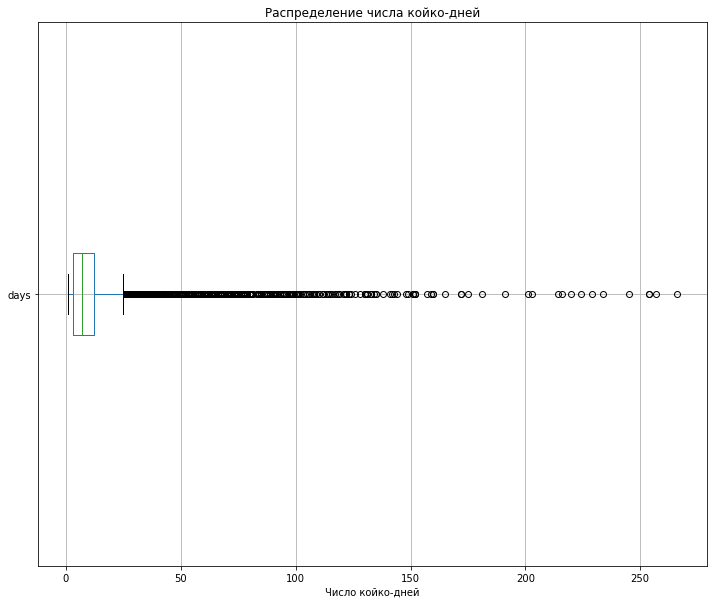

In [22]:
boxplot = hospital_2.boxplot(column='days',
                     vert=False, 
                     figsize=(12, 10))

# Добавляем заголовок и метку оси X
boxplot.set_title('Распределение числа койко-дней')
boxplot.set_xlabel('Число койко-дней')

plt.show()

In [23]:
hospital['days'].describe()

count    125261.000000
mean          8.784546
std           8.728592
min           1.000000
25%           3.000000
50%           7.000000
75%          12.000000
max         266.000000
Name: days, dtype: float64

Изучите среднюю длительность госпитализации по отделениям. Изучите десять отделений, где длительности госпитализации пациентов наибольшая

In [24]:
days_depart=hospital_2.groupby('department')['days'].mean()

In [27]:
days_depart=days_depart.reset_index()

In [30]:
top_depart=days_depart.sort_values(by='days',axis=0, ascending=False).head(10)

In [31]:
print(top_depart)

                                           department       days
14                Отделение анестезиологии-реанимации  45.179487
20                       ПЦ ОАРИТН №1 (новорожденных)  28.723214
21  ПЦ Отделение Анестезиологии-реанимации для дет...  26.438095
24  ПЦ Отделение патологии новорожденных и детей г...  22.200586
22  ПЦ Отделение вспомогательных репродуктивных те...  21.297802
3   Дневной стационар Кожно-венерологического отде...  14.027322
2   Дневной стационар Гастроэнтерологического отде...  13.339286
12                       Микрохирургическое отделение  13.293007
27                        Педиатрическое отделение №1  12.824642
8         Дневной стационар эндокринологического отд.  12.766667


In [32]:
import seaborn as sns

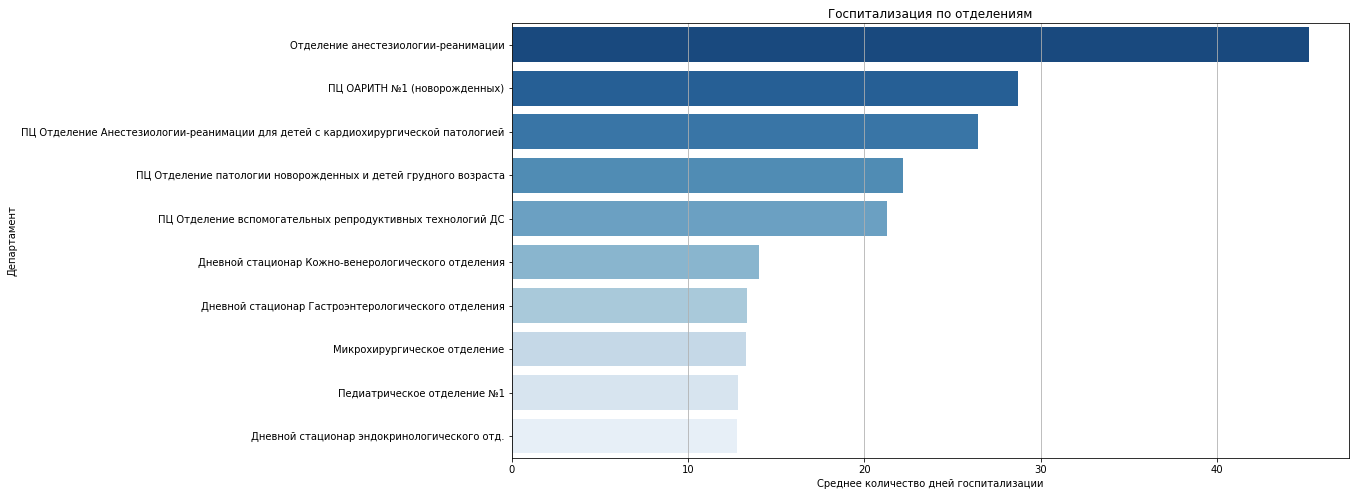

In [33]:
plt.figure(figsize=(15, 8))
sns.barplot(data=top_depart, x="days", y="department", palette="Blues_r")
plt.title("Госпитализация по отделениям")
plt.xlabel("Среднее количество дней госпитализации")
plt.ylabel("Департамент")
plt.grid(axis='x')
plt.show()

Исследуйте динамику количества поступивших пациентов в разные месяцы (учитывая различия в годах).

In [35]:
hospital_3=hospital_2.copy()

In [36]:
hospital_3['month']=hospital_3['date_in'].dt.to_period('M')

In [52]:
patients=hospital_3.groupby('month')['id'].nunique()

In [53]:
patients.head(10)

month
2019-01    1911
2019-02    1769
2019-03    2024
2019-04    1924
2019-05    2282
2019-06    1759
2019-07    1146
2019-08    1481
2019-09    1904
2019-10    2268
Freq: M, Name: id, dtype: int64

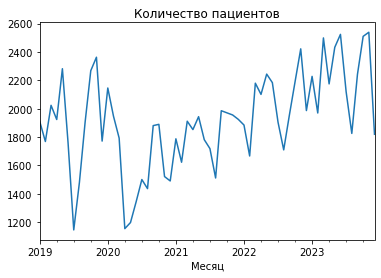

In [54]:
patients.plot(kind='line',
              legend=False
              )

plt.title("Количество пациентов")
# Подписываем оси
plt.xlabel('Месяц')
plt.show()

Руководство хочет проверить, отличается ли средняя длительность госпитализации пациентов от стандартного семидневного срока. Проверьте эту гипотезу.

In [41]:
import scipy.stats as st

def print_stattest_results(p_value:float, alpha:float = 0.05):
    if p_value<alpha:
        print(f'Полученное значение p_value={p_value} меньше критического уровня alpha={alpha}. Принимаем альтернативную гипотезу.') 
    else:
        print(f'Полученное значение p_value={p_value} больше критического уровня alpha={alpha}. Опровергнуть нулевую гипотезу нельзя.')
    # Напишите код для функции здесь

In [42]:
null_hypothesis = 7
pat_days =hospital_3['days']

results = st.ttest_1samp (pat_days , null_hypothesis, alternative='two-sided' )
p_value =results.pvalue
print_stattest_results(p_value)

Полученное значение p_value=0.0 меньше критического уровня alpha=0.05. Принимаем альтернативную гипотезу.


Медицинский отдел хочет проверить, превышает ли средняя длительность госпитализации пациентов 10 дней.

In [43]:
null_hypothesis = 10
pat_days =hospital_3['days']

results = st.ttest_1samp (pat_days , null_hypothesis, alternative='greater' )
p_value =results.pvalue
print_stattest_results(p_value)

Полученное значение p_value=1.0 больше критического уровня alpha=0.05. Опровергнуть нулевую гипотезу нельзя.


Необходимо проверить, отличается ли средняя длительность лечения в стационаре между плановыми и экстренными пациентами.

In [50]:
plan=hospital_3[hospital_3['plan_extr']=='Плановая']['days']
extr=hospital_3[hospital_3['plan_extr']=='Экстренная']['days']

In [51]:
results = st.ttest_ind(plan,extr,alternative='two-sided')
p_value =results.pvalue
print_stattest_results(p_value)

Полученное значение p_value=0.0 меньше критического уровня alpha=0.05. Принимаем альтернативную гипотезу.
